In [1]:
import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [2]:
#Load the trained model and the held-out test set.

test_X = joblib.load("data/processed/test_X.joblib")
test_y = joblib.load("data/processed/test_y.joblib")

rf_model_multi = joblib.load('models/network_anomaly_detection_model.joblib')

In [3]:
# Predict on the test set
multi_predictions = rf_model_multi.predict(test_X)
class_labels = ['Normal', 'DoS', 'Probe', 'Privilege', 'Access']

accuracy = accuracy_score(test_y, multi_predictions)
precision = precision_score(test_y, multi_predictions, average='macro')
recall = recall_score(test_y, multi_predictions, average='macro')
f1 = f1_score(test_y, multi_predictions, average='macro')

print("Test Set Evaluation:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

Test Set Evaluation:
Accuracy:  0.9950
Precision: 0.9068
Recall:    0.9220
F1-Score:  0.9142


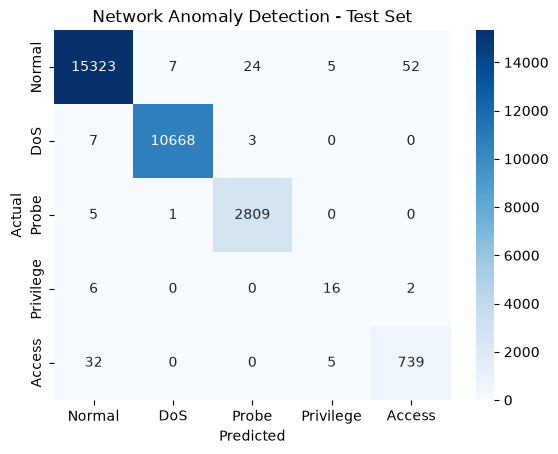

In [4]:
# Confusion matrix for the test set
conf_matrix = confusion_matrix(test_y, multi_predictions)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Network Anomaly Detection - Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [5]:
# Per-class results for the test set
print(classification_report(test_y, multi_predictions, target_names=class_labels))

              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00     15411
         DoS       1.00      1.00      1.00     10678
       Probe       0.99      1.00      0.99      2815
   Privilege       0.62      0.67      0.64        24
      Access       0.93      0.95      0.94       776

    accuracy                           0.99     29704
   macro avg       0.91      0.92      0.91     29704
weighted avg       1.00      0.99      1.00     29704



In [6]:
# Intrusion detection summary: attack vs. normal
# Rows = actual class, columns = predicted class, index 0 = Normal

total_attacks = conf_matrix[1:, :].sum()     # all rows except Normal
missed_attacks = conf_matrix[1:, 0].sum()    # attacks predicted as Normal
detection_rate = 1 - missed_attacks / total_attacks

total_normal = conf_matrix[0, :].sum()       # the Normal row
false_alarms = conf_matrix[0, 1:].sum()      # Normal predicted as any attack
false_alarm_rate = false_alarms / total_normal

print("Intrusion Detection Summary:")
print(f"Detection rate:   {detection_rate:.2%}  ({total_attacks - missed_attacks} of {total_attacks} attacks flagged)")
print(f"False alarm rate: {false_alarm_rate:.2%}  ({false_alarms} of {total_normal} normal connections flagged)")

Intrusion Detection Summary:
Detection rate:   99.65%  (14243 of 14293 attacks flagged)
False alarm rate: 0.57%  (88 of 15411 normal connections flagged)


In [7]:
# Live demo: classify a sample of real test connections

# Pick 2 random connections from each class (reproducible)
sample_idx = test_y.groupby(test_y).sample(n=3, random_state=1337).index
sample_X = test_X.loc[sample_idx]
sample_y = test_y.loc[sample_idx]

# Predictions and how confident the model is in each one
predictions = rf_model_multi.predict(sample_X)
confidence = rf_model_multi.predict_proba(sample_X).max(axis=1)

# Turn one-hot columns (e.g. service_http) back into readable names (http)
def decode(prefix):
    cols = [c for c in sample_X.columns if c.startswith(prefix + "_")]
    return sample_X[cols].astype(int).idxmax(axis=1).str.removeprefix(prefix + "_")

demo = pd.DataFrame({
    "protocol":   decode("protocol_type"),
    "service":    decode("service"),
    "flag":       decode("flag"),
    "src_bytes":  sample_X["src_bytes"],
    "dst_bytes":  sample_X["dst_bytes"],
    "actual":     [class_labels[i] for i in sample_y],
    "predicted":  [class_labels[i] for i in predictions],
    "confidence": confidence,
})
demo["correct"] = demo["actual"] == demo["predicted"]

demo.style.format({"confidence": "{:.0%}"}).hide(axis="index")

protocol,service,flag,src_bytes,dst_bytes,actual,predicted,confidence,correct
tcp,http,SF,222,10378,Normal,Normal,100%,True
tcp,smtp,SF,1529,370,Normal,Normal,100%,True
tcp,http,SF,234,406,Normal,Normal,100%,True
tcp,private,S0,0,0,DoS,DoS,100%,True
icmp,ecr_i,SF,520,0,DoS,DoS,100%,True
icmp,ecr_i,SF,1008,0,DoS,DoS,100%,True
tcp,private,REJ,0,0,Probe,Probe,100%,True
udp,private,SF,1,0,Probe,Probe,97%,True
tcp,daytime,RSTR,0,0,Probe,Probe,96%,True
tcp,ftp_data,SF,45,0,Privilege,Privilege,60%,True


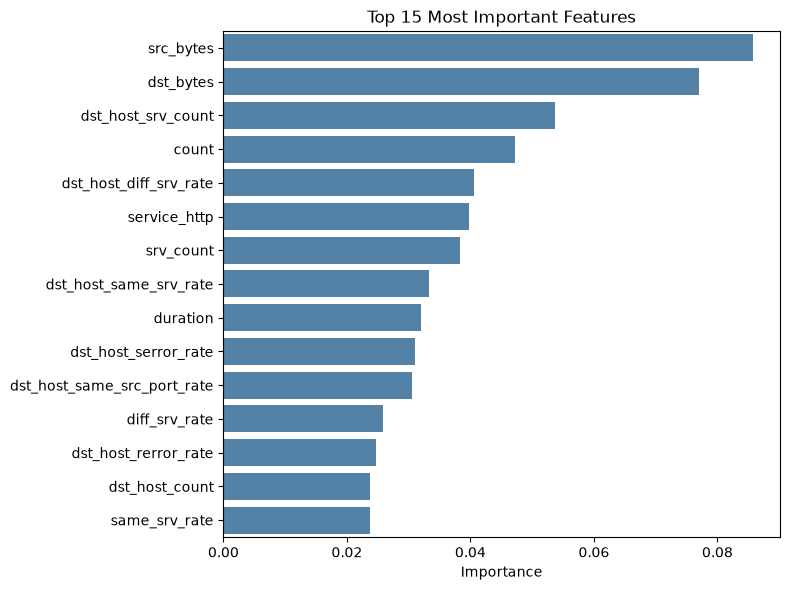

In [8]:
# Feature importance: which features the model relies on most
importances = pd.Series(rf_model_multi.feature_importances_, index=rf_model_multi.feature_names_in_)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=top_features.values, y=top_features.index, color="steelblue")
plt.title("Top 15 Most Important Features")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [9]:
print(f"flag (all columns): {importances[importances.index.str.startswith('flag_')].sum():.3f}")
print(f"logged_in:          {importances['logged_in']:.3f}")

flag (all columns): 0.044
logged_in:          0.017
